# DAY 3 - Feature Engineering

## What we do today:
1. Fix all data quality issues
2. Convert text columns to numbers
3. Create 7 powerful new features
4. Save the clean dataset

Run each cell one by one using Shift+Enter

## CELL 1 - Import Libraries and Load Raw Data
We always load from data/raw/ (original untouched data)
We will save our cleaned version to data/processed/

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('docs', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Load the ORIGINAL raw data - never modify this file
df = pd.read_csv('data/raw/telco_churn.csv')

print(f'Raw data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print()
print('First 3 rows:')
print(df.head(3))

Raw data loaded: 7043 rows, 21 columns

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      P

## CELL 2 - Fix Problem 1: Drop customerID
customerID is just a unique ID for each customer.
It has NO relationship with churn.
Keeping it would confuse the model.

In [7]:
print('Before dropping customerID:')
print(f'  Columns: {df.shape[1]}')
print(f'  Sample customerID values: {df["customerID"].head(3).tolist()}')

# Drop customerID - useless for prediction
df = df.drop('customerID', axis=1)

print()
print('After dropping customerID:')
print(f'  Columns: {df.shape[1]}')
print()
print('Remaining columns:')
print(df.columns.tolist())

Before dropping customerID:
  Columns: 21
  Sample customerID values: ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK']

After dropping customerID:
  Columns: 20

Remaining columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## CELL 3 - Fix Problem 2: TotalCharges Column
TotalCharges is stored as TEXT not as a NUMBER.
Some rows have blank spaces instead of a number.
We must convert it to a proper number.

In [8]:
print('BEFORE FIX:')
print(f'  TotalCharges type: {df["TotalCharges"].dtype}')
print(f'  Sample values: {df["TotalCharges"].head(5).tolist()}')

# Find blank rows
blank_rows = df[df['TotalCharges'].str.strip() == '']
print(f'  Blank rows found: {len(blank_rows)}')
print()

# FIX: Convert to number, blanks become NaN, then fill with 0
# errors='coerce' means: if cant convert, put NaN instead of crashing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('AFTER FIX:')
print(f'  TotalCharges type: {df["TotalCharges"].dtype}')
print(f'  Missing values: {df["TotalCharges"].isnull().sum()}')
print(f'  Min: ${df["TotalCharges"].min():.2f}')
print(f'  Max: ${df["TotalCharges"].max():.2f}')
print()
print('TotalCharges is now a proper number column!')

BEFORE FIX:
  TotalCharges type: object
  Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65']
  Blank rows found: 11

AFTER FIX:
  TotalCharges type: float64
  Missing values: 0
  Min: $0.00
  Max: $8684.80

TotalCharges is now a proper number column!


## CELL 4 - Fix Problem 3: Convert Target Column
Churn column has Yes/No text.
ML models need numbers not text.
Yes = 1 (churned), No = 0 (stayed)

In [9]:
print('BEFORE:')
print(f'  Churn unique values: {df["Churn"].unique()}')
print(f'  Churn type: {df["Churn"].dtype}')

# Convert Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print()
print('AFTER:')
print(f'  Churn unique values: {df["Churn"].unique()}')
print(f'  Churn type: {df["Churn"].dtype}')
print(f'  Churned (1): {df["Churn"].sum():,} customers')
print(f'  Stayed  (0): {(df["Churn"]==0).sum():,} customers')

BEFORE:
  Churn unique values: ['No' 'Yes']
  Churn type: object

AFTER:
  Churn unique values: [0 1]
  Churn type: int64
  Churned (1): 1,869 customers
  Stayed  (0): 5,174 customers


## CELL 5 - Convert All Text Columns to Numbers
ML models CANNOT understand text like Male/Female or Yes/No.
We use Label Encoding to convert text to numbers.
Example: Male=0, Female=1 | Yes=0, No=1

In [10]:
from sklearn.preprocessing import LabelEncoder

# Find all text columns (except Churn which we already fixed)
text_columns = df.select_dtypes(include='object').columns.tolist()

print(f'Text columns to convert: {len(text_columns)}')
print(text_columns)
print()

# Store encoding mappings so we understand what numbers mean
encoding_map = {}
le = LabelEncoder()

for col in text_columns:
    original_values = df[col].unique().tolist()
    df[col] = le.fit_transform(df[col])
    new_values = df[col].unique().tolist()
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col}: {original_values} -> numbers')

print()
print('All text columns converted to numbers!')
print()
print('Example - Contract column mapping:')
print(f'  {encoding_map["Contract"]}')

Text columns to convert: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

  gender: ['Female', 'Male'] -> numbers
  Partner: ['Yes', 'No'] -> numbers
  Dependents: ['No', 'Yes'] -> numbers
  PhoneService: ['No', 'Yes'] -> numbers
  MultipleLines: ['No phone service', 'No', 'Yes'] -> numbers
  InternetService: ['DSL', 'Fiber optic', 'No'] -> numbers
  OnlineSecurity: ['No', 'Yes', 'No internet service'] -> numbers
  OnlineBackup: ['Yes', 'No', 'No internet service'] -> numbers
  DeviceProtection: ['No', 'Yes', 'No internet service'] -> numbers
  TechSupport: ['No', 'Yes', 'No internet service'] -> numbers
  StreamingTV: ['No', 'Yes', 'No internet service'] -> numbers
  StreamingMovies: ['No', 'Yes', 'No internet service'] -> numbers
  Contract: ['Month-to-month', 'One year', 'Two year'] -> numbe

## CELL 6 - Create New Feature 1 and 2: Customer Age Groups
is_new_customer: Customer in first 6 months (highest churn risk)
is_loyal_customer: Customer for 2+ years (lowest churn risk)

WHY: We discovered in Day 2 that tenure group is the strongest signal

In [11]:
# Feature 1: Is this a new customer? (first 6 months)
df['is_new_customer'] = (df['tenure'] <= 6).astype(int)

# Feature 2: Is this a loyal long-term customer? (2+ years)
df['is_loyal_customer'] = (df['tenure'] >= 24).astype(int)

# Verify these features capture the right groups
print('=== NEW FEATURE: is_new_customer ===')
print(f'  New customers (tenure <= 6 months): {df["is_new_customer"].sum():,}')
new_churn = df[df['is_new_customer']==1]['Churn'].mean() * 100
print(f'  Their churn rate: {new_churn:.1f}%')
print()

print('=== NEW FEATURE: is_loyal_customer ===')
print(f'  Loyal customers (tenure >= 24 months): {df["is_loyal_customer"].sum():,}')
loyal_churn = df[df['is_loyal_customer']==1]['Churn'].mean() * 100
print(f'  Their churn rate: {loyal_churn:.1f}%')
print()

print(f'New customers churn at {new_churn:.0f}% vs loyal customers at {loyal_churn:.0f}%')
print('These features will be very useful for the model!')

=== NEW FEATURE: is_new_customer ===
  New customers (tenure <= 6 months): 1,481
  Their churn rate: 52.9%

=== NEW FEATURE: is_loyal_customer ===
  Loyal customers (tenure >= 24 months): 3,927
  Their churn rate: 14.3%

New customers churn at 53% vs loyal customers at 14%
These features will be very useful for the model!


## CELL 7 - Create New Feature 3: Charges Per Month
TotalCharges divided by tenure = average monthly payment.
This captures the true payment pattern over time.
A new customer with $100 total paid very different from a 10-year customer with $100 total.

In [12]:
# Feature 3: Average charge per month
# We add 1 to tenure to avoid dividing by zero for new customers
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

print('=== NEW FEATURE: charges_per_month ===')
print(f'  Min value : ${df["charges_per_month"].min():.2f}')
print(f'  Max value : ${df["charges_per_month"].max():.2f}')
print(f'  Average   : ${df["charges_per_month"].mean():.2f}')
print()

# Compare for churned vs stayed
churned_cpm = df[df['Churn']==1]['charges_per_month'].mean()
stayed_cpm = df[df['Churn']==0]['charges_per_month'].mean()
print(f'  Churned customers avg: ${churned_cpm:.2f}/month')
print(f'  Stayed  customers avg: ${stayed_cpm:.2f}/month')

=== NEW FEATURE: charges_per_month ===
  Min value : $0.00
  Max value : $118.97
  Average   : $58.99

  Churned customers avg: $62.68/month
  Stayed  customers avg: $57.66/month


## CELL 8 - Create New Feature 4: Number of Services
Count how many addon services each customer has.
More services = more invested in the product = less likely to leave.
Think of it like: if you use 5 features of an app, you wont delete it easily.

In [13]:
# These are all the addon service columns
# After label encoding, Yes=1 or Yes=2 depending on column
# Easier to check original data pattern

# Reload original to check encoding
df_orig = pd.read_csv('data/raw/telco_churn.csv')

service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count services where value is 'Yes'
num_services = pd.Series(0, index=df_orig.index)
for col in service_cols:
    num_services += (df_orig[col] == 'Yes').astype(int)

df['num_services'] = num_services

print('=== NEW FEATURE: num_services ===')
print('Distribution of number of services:')
print(df['num_services'].value_counts().sort_index())
print()

# Show churn rate by number of services
print('Churn rate by number of services:')
churn_by_services = df.groupby('num_services')['Churn'].mean() * 100
for services, rate in churn_by_services.items():
    bar = 'X' * int(rate / 3)
    print(f'  {services} services: {rate:.1f}% churn  {bar}')

=== NEW FEATURE: num_services ===
Distribution of number of services:
num_services
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

Churn rate by number of services:
  0 services: 43.8% churn  XXXXXXXXXXXXXX
  1 services: 21.1% churn  XXXXXXX
  2 services: 32.8% churn  XXXXXXXXXX
  3 services: 36.5% churn  XXXXXXXXXXXX
  4 services: 31.3% churn  XXXXXXXXXX
  5 services: 25.6% churn  XXXXXXXX
  6 services: 22.5% churn  XXXXXXX
  7 services: 12.4% churn  XXXX
  8 services: 5.3% churn  X


## CELL 9 - Create New Feature 5 and 6: Support and Value
has_support: Does customer have TechSupport OR OnlineSecurity?
is_high_value: Does customer pay more than $70/month?

Both discovered as important patterns in Day 2 analysis.

In [14]:
# Reload original for text comparison
df_orig = pd.read_csv('data/raw/telco_churn.csv')

# Feature 5: Has any support service
has_tech = (df_orig['TechSupport'] == 'Yes')
has_security = (df_orig['OnlineSecurity'] == 'Yes')
df['has_support'] = (has_tech | has_security).astype(int)

# Feature 6: Is high value customer
df['is_high_value'] = (df['MonthlyCharges'] > 70).astype(int)

print('=== NEW FEATURE: has_support ===')
support_churn = df[df['has_support']==1]['Churn'].mean() * 100
no_support_churn = df[df['has_support']==0]['Churn'].mean() * 100
print(f'  With support    : {support_churn:.1f}% churn rate')
print(f'  Without support : {no_support_churn:.1f}% churn rate')
print(f'  No support = {no_support_churn/support_churn:.1f}x higher churn risk!')
print()

print('=== NEW FEATURE: is_high_value ===')
high_churn = df[df['is_high_value']==1]['Churn'].mean() * 100
low_churn = df[df['is_high_value']==0]['Churn'].mean() * 100
print(f'  High value (>$70/month) : {high_churn:.1f}% churn rate')
print(f'  Normal value            : {low_churn:.1f}% churn rate')

=== NEW FEATURE: has_support ===
  With support    : 17.1% churn rate
  Without support : 33.4% churn rate
  No support = 2.0x higher churn risk!

=== NEW FEATURE: is_high_value ===
  High value (>$70/month) : 35.4% churn rate
  Normal value            : 17.4% churn rate


## CELL 10 - Create New Feature 7: Contract Risk Score
Month-to-month contract = highest risk = score 2
One year contract = medium risk = score 1
Two year contract = lowest risk = score 0

This gives the model a numeric risk level directly.

In [15]:
df_orig = pd.read_csv('data/raw/telco_churn.csv')

# Map contract type to risk score
contract_risk_map = {
    'Month-to-month': 2,
    'One year': 1,
    'Two year': 0
}
df['contract_risk'] = df_orig['Contract'].map(contract_risk_map)

print('=== NEW FEATURE: contract_risk ===')
print('Mapping:')
for contract, risk in contract_risk_map.items():
    count = (df['contract_risk'] == risk).sum()
    churn_rate = df[df['contract_risk']==risk]['Churn'].mean() * 100
    print(f'  {contract:<20} -> risk={risk} | {count:,} customers | {churn_rate:.1f}% churn')

print()
print('Higher risk score = more likely to churn')
print('Model will learn this pattern very easily!')

=== NEW FEATURE: contract_risk ===
Mapping:
  Month-to-month       -> risk=2 | 3,875 customers | 42.7% churn
  One year             -> risk=1 | 1,473 customers | 11.3% churn
  Two year             -> risk=0 | 1,695 customers | 2.8% churn

Higher risk score = more likely to churn
Model will learn this pattern very easily!


## CELL 11 - See All Features Together
Show the complete dataset with all original + new features.

In [16]:
print('=== COMPLETE DATASET AFTER FEATURE ENGINEERING ===')
print()
print(f'Total rows    : {df.shape[0]:,}')
print(f'Total columns : {df.shape[1]}')
print()

original_cols = 19  # after dropping customerID
new_cols = df.shape[1] - original_cols

print(f'Original features : {original_cols}')
print(f'New features added: {new_cols}')
print()

print('NEW FEATURES CREATED:')
new_feature_list = ['is_new_customer', 'is_loyal_customer', 'charges_per_month',
                    'num_services', 'has_support', 'is_high_value', 'contract_risk']
for feat in new_feature_list:
    print(f'  + {feat}')

print()
print('Sample of new features for first 5 customers:')
print(df[new_feature_list].head())

=== COMPLETE DATASET AFTER FEATURE ENGINEERING ===

Total rows    : 7,043
Total columns : 27

Original features : 19
New features added: 8

NEW FEATURES CREATED:
  + is_new_customer
  + is_loyal_customer
  + charges_per_month
  + num_services
  + has_support
  + is_high_value
  + contract_risk

Sample of new features for first 5 customers:
   is_new_customer  is_loyal_customer  charges_per_month  num_services  \
0                1                  0          14.925000             1   
1                0                  1          53.985714             3   
2                1                  0          36.050000             3   
3                0                  1          40.016304             3   
4                1                  0          50.550000             1   

   has_support  is_high_value  contract_risk  
0            0              0              2  
1            1              0              1  
2            1              0              2  
3            1           

## CELL 12 - Check No Missing Values Remain
Before saving, make sure there are zero missing values.
ML models crash if they find NaN values.

In [17]:
print('=== MISSING VALUES CHECK ===')
missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print('PERFECT! Zero missing values in any column!')
    print('Dataset is clean and ready for modeling.')
else:
    print(f'WARNING: {total_missing} missing values found!')
    print(missing[missing > 0])
    print('Fix these before saving!')

print()
print(f'Dataset shape: {df.shape}')
print(f'All values numeric: {df.select_dtypes(include="object").shape[1] == 0}')

=== MISSING VALUES CHECK ===
PERFECT! Zero missing values in any column!
Dataset is clean and ready for modeling.

Dataset shape: (7043, 27)
All values numeric: True


## CELL 13 - Save the Clean Dataset
Save to data/processed/ folder.
Day 4 onwards will always load from here, not from raw.

In [18]:
PROCESSED_PATH = 'data/processed/churn_clean.csv'

df.to_csv(PROCESSED_PATH, index=False)

# Verify it saved correctly
verify = pd.read_csv(PROCESSED_PATH)

print('=== DATASET SAVED ===')
print(f'  Saved to  : {PROCESSED_PATH}')
print(f'  Rows      : {verify.shape[0]:,}')
print(f'  Columns   : {verify.shape[1]}')
print()
print('All columns in saved file:')
for i, col in enumerate(verify.columns, 1):
    marker = '(NEW)' if col in ['is_new_customer', 'is_loyal_customer',
                                  'charges_per_month', 'num_services',
                                  'has_support', 'is_high_value',
                                  'contract_risk'] else ''
    print(f'  {i:2}. {col} {marker}')

=== DATASET SAVED ===
  Saved to  : data/processed/churn_clean.csv
  Rows      : 7,043
  Columns   : 27

All columns in saved file:
   1. gender 
   2. SeniorCitizen 
   3. Partner 
   4. Dependents 
   5. tenure 
   6. PhoneService 
   7. MultipleLines 
   8. InternetService 
   9. OnlineSecurity 
  10. OnlineBackup 
  11. DeviceProtection 
  12. TechSupport 
  13. StreamingTV 
  14. StreamingMovies 
  15. Contract 
  16. PaperlessBilling 
  17. PaymentMethod 
  18. MonthlyCharges 
  19. TotalCharges 
  20. Churn 
  21. is_new_customer (NEW)
  22. is_loyal_customer (NEW)
  23. charges_per_month (NEW)
  24. num_services (NEW)
  25. has_support (NEW)
  26. is_high_value (NEW)
  27. contract_risk (NEW)


## CELL 14 - Visualize New Features vs Churn
Quick chart to confirm our new features actually capture churn patterns.

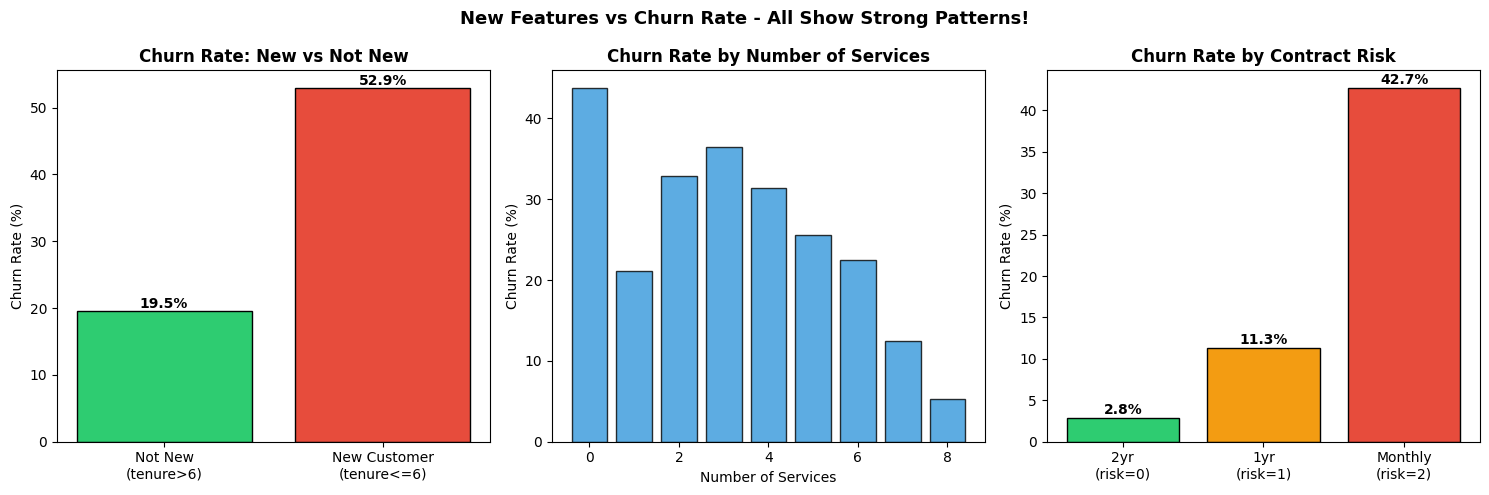

Chart saved to docs/new_features_validation.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# is_new_customer vs churn
new_vs_churn = df.groupby('is_new_customer')['Churn'].mean() * 100
axes[0].bar(['Not New\n(tenure>6)', 'New Customer\n(tenure<=6)'],
            new_vs_churn.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Rate: New vs Not New', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(new_vs_churn.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# num_services vs churn
services_churn = df.groupby('num_services')['Churn'].mean() * 100
axes[1].bar(services_churn.index, services_churn.values,
            color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[1].set_xlabel('Number of Services')
axes[1].set_ylabel('Churn Rate (%)')

# contract_risk vs churn
risk_churn = df.groupby('contract_risk')['Churn'].mean() * 100
axes[2].bar(['2yr\n(risk=0)', '1yr\n(risk=1)', 'Monthly\n(risk=2)'],
            risk_churn.values,
            color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[2].set_title('Churn Rate by Contract Risk', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(risk_churn.values):
    axes[2].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('New Features vs Churn Rate - All Show Strong Patterns!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/new_features_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/new_features_validation.png')

In [20]:
print('================================================')
print('DAY 3 COMPLETE!')
print('================================================')
print()
print('What you did today:')
print('  Dropped useless customerID column')
print('  Fixed TotalCharges from text to number')
print('  Converted target Churn to 0 and 1')
print('  Converted all 15 text columns to numbers')
print('  Created 7 powerful new features')
print('  Verified zero missing values')
print('  Saved clean dataset to data/processed/')
print()
print('File saved:')
print('  data/processed/churn_clean.csv')
print()
print('NEXT: Day 4 - Build Baseline Model + Setup MLflow')

DAY 3 COMPLETE!

What you did today:
  Dropped useless customerID column
  Fixed TotalCharges from text to number
  Converted target Churn to 0 and 1
  Converted all 15 text columns to numbers
  Created 7 powerful new features
  Verified zero missing values
  Saved clean dataset to data/processed/

File saved:
  data/processed/churn_clean.csv

NEXT: Day 4 - Build Baseline Model + Setup MLflow
